In [56]:
from database.adatabase import ADatabase
import pandas as pd
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
from datetime import datetime, timedelta, timezone
from xgboost import XGBRegressor
import random

In [22]:
db = ADatabase("algo")
market = ADatabase("market")
market.connect()
russell1000 = market.retrieve("russell1000")
market.disconnect()

In [228]:
tickers = russell1000["ticker"].values
training_year = datetime.now().year - 3
holding_period = 5
today = datetime.now()
weekday = today.weekday() - 1 if today.weekday() != 0 else 4
factors = ["historical_return","skurtosis","skew","kurtosis","average_return","coefficient_of_variance","price_to_rolling","price_to_bollinger"]

In [229]:
market.connect()
prices = []
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))[["date","week","month","weekday","ticker","adjclose"]]
        ticker_prices.sort_values("date",inplace=True)
        ticker_prices["historical_return"] = (ticker_prices["adjclose"] - ticker_prices["adjclose"].shift(5)) / ticker_prices["adjclose"].shift(5)
        ticker_prices["skew"] = ticker_prices["historical_return"].rolling(100).skew()
        ticker_prices["kurtosis"] = ticker_prices["historical_return"].rolling(100).kurt()
        ticker_prices["skurtosis"] = ticker_prices["skew"] * ticker_prices["kurtosis"]
        ticker_prices["average_return"] = ticker_prices["historical_return"].rolling(100).mean()
        ticker_prices["coefficient_of_variance"] = ticker_prices["adjclose"].rolling(100).std() / ticker_prices["adjclose"].rolling(100).mean()
        ticker_prices["price_to_rolling"] = ticker_prices["adjclose"] / ticker_prices["adjclose"].rolling(100).mean()
        ticker_prices["price_to_bollinger"] = ticker_prices["adjclose"] / (ticker_prices["adjclose"].rolling(100).mean() + 2 * ticker_prices["adjclose"].rolling(100).std()) 
        ticker_prices["random"] = [random.randint(0,1009) for x in ticker_prices.iterrows()]
        ticker_prices["buy_price"] = ticker_prices["adjclose"].shift(-1)
        ticker_prices["buy_date"] = ticker_prices["date"].shift(-1)
        ticker_prices["sell_price"] = ticker_prices["adjclose"].shift(-holding_period)
        ticker_prices["sell_date"] = ticker_prices["date"] + timedelta(days=holding_period/5*7)
        ticker_prices["y"] = (ticker_prices["sell_price"] - ticker_prices["buy_price"]) / ticker_prices ["buy_price"]
        training_data = ticker_prices.iloc[100:200].dropna()
        simulation = ticker_prices.iloc[200:]
        model = XGBRegressor()
        model.fit(training_data[factors],training_data["y"])
        simulation["expected_return"] = model.predict(simulation[factors])
        if simulation.index.size > 0:
            prices.append(simulation)
    except Exception as e:
        print(ticker,str(e))
        continue
market.disconnect()
sim = pd.concat(prices).reset_index(drop=True)

model_prep: 100%|██████████| 1009/1009 [04:21<00:00,  3.86it/s]


In [278]:
positions = 10
hedge_percentage = 0.03
sim["return"] = sim["y"] * (1/positions) * 0.995
sim["return"] = [max(float(-hedge_percentage/positions),x) for x in sim["return"]]
sim["month"] = [x.month for x in sim["date"]]
sim.sort_values("date",inplace=True)
trades = sim[sim["weekday"]==4].copy()
trades = trades[trades["week"] % int(holding_period/5) == 0]
trades = processor.column_date_processing(trades)
market.connect()
benchmark = processor.column_date_processing(market.query("prices",{"ticker":"AMZN"}))[["date","adjclose"]]
market.disconnect()

In [329]:
analysis = []
for valuation_method in factors + ["expected_return","random"]:
    for ascending in [True,False]:
        iteration_trades = trades.copy().sort_values(valuation_method,ascending=ascending).groupby(["date"]).nth([i for i in range(positions)]).reset_index()
        portfolio = iteration_trades[["date","return"]].groupby("date").sum().reset_index()
        portfolio.sort_values("date",inplace=True)
        portfolio = portfolio[(portfolio["date"]>portfolio["date"].min()) & (portfolio["date"]<portfolio["date"].max())]
        portfolio = portfolio.merge(benchmark,on="date")
        portfolio["benchmark_cumulative_return"] = (portfolio["adjclose"] - portfolio["adjclose"].iloc[0]) / portfolio["adjclose"].iloc[0] + 1
        portfolio["return"] = portfolio["return"] + 1
        portfolio["rolling_return"] = portfolio["return"].rolling(10).mean() 
        portfolio["skew"] = portfolio["return"].rolling(10).skew()
        portfolio["kurtosis"] = portfolio["return"].rolling(10).kurt()
        portfolio["cumulative_return"] = portfolio["return"].cumprod()
        portfolio["upper"] = portfolio["cumulative_return"].rolling(10).mean() +  2 * portfolio["cumulative_return"].rolling(10).std() 
        portfolio["lower"] = portfolio["cumulative_return"].rolling(10).mean() -  2 * portfolio["cumulative_return"].rolling(10).std() 
        analysis.append({
            "vm":valuation_method,
            "asc":ascending,
            "skew": iteration_trades["return"].skew(),
            "kurtosis": iteration_trades["return"].kurt(),
            "cr":portfolio["cumulative_return"].tail(1).item(),
            "std":portfolio["cumulative_return"].std(),
            "coefficient_of_variance":portfolio["cumulative_return"].std()/portfolio["cumulative_return"].tail(1).item(),
            "return_to_std":portfolio["cumulative_return"].tail(1).item() / portfolio["cumulative_return"].std(),
            "treynor":portfolio["cumulative_return"].tail(1).item() / portfolio["cumulative_return"].cov(portfolio["benchmark_cumulative_return"]),
            "lower_bound":portfolio["lower"].tail(1).item(),
            "winrate":iteration_trades[iteration_trades["return"]>0].index.size/iteration_trades.index.size,
            "average_win":iteration_trades[iteration_trades["return"]>0]["return"].median() * 10
        })

In [330]:
a = pd.DataFrame(analysis).sort_values("lower_bound",ascending=False)
a

,vm,asc,skew,kurtosis,cr,std,coefficient_of_variance,return_to_std,treynor,lower_bound,winrate,average_win
14,price_to_bollinger,True,2.096295,5.462937,5.099183,1.081977,0.212186,4.712838,26.248251,3.524498,0.504839,0.058102
11,coefficient_of_variance,False,4.811493,47.847890,4.530616,0.970878,0.214293,4.666516,25.543457,3.377466,0.514516,0.046901
12,price_to_rolling,True,2.074316,5.253941,5.001892,1.036024,0.207126,4.827969,27.122693,3.318439,0.493548,0.059415
8,average_return,True,2.154608,6.126982,4.422040,0.898994,0.203299,4.918875,27.369824,3.072876,0.501613,0.051384
0,historical_return,True,2.287149,7.736501,3.477854,0.632965,0.181999,5.494543,30.646178,2.346171,0.525806,0.041870
17,expected_return,False,2.301288,7.477957,2.960330,0.516376,0.174432,5.732893,31.741647,2.063533,0.524194,0.035095
16,expected_return,True,1.991315,5.883892,2.408877,0.358563,0.148851,6.718136,37.281249,1.799839,0.514516,0.036334
7,kurtosis,False,2.242213,8.398983,1.926792,0.249762,0.129626,7.714529,41.684446,1.686965,0.535484,0.025505
1,historical_return,False,2.063068,6.398110,2.246032,0.324418,0.144440,6.923274,37.302620,1.599921,0.487097,0.038058
9,average_return,False,2.239506,9.079814,2.122080,0.308716,0.145478,6.873889,37.258021,1.599569,0.519355,0.035992


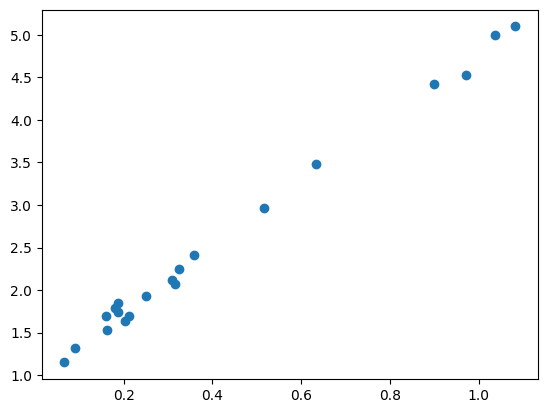

In [331]:
plt.scatter(a["std"],a["cr"])
plt.show()

In [337]:
valuation_method = "price_to_bollinger"
ascending = True

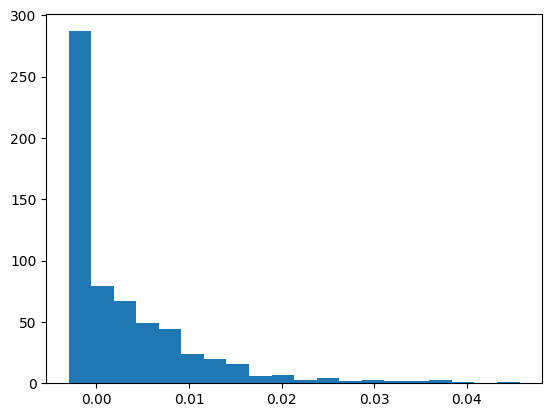

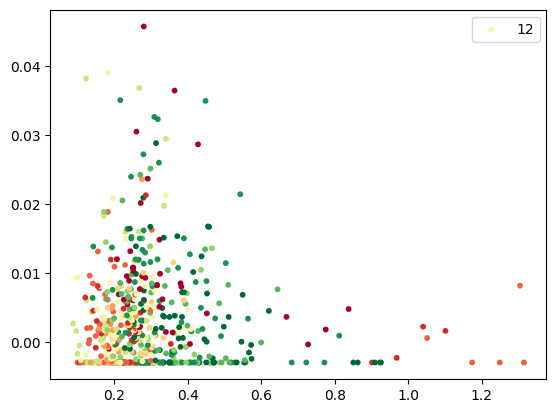

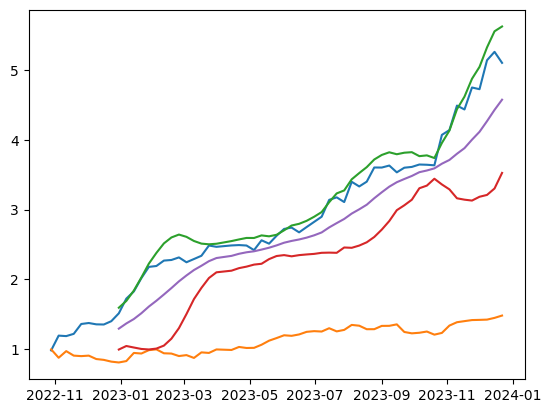

In [343]:
try:
    iteration_trades = trades.copy().sort_values(valuation_method,ascending=ascending).groupby(["date"]).nth([i for i in range(positions)]).reset_index()
    portfolio = iteration_trades[["date","return"]].groupby("date").sum().reset_index()
    portfolio.sort_values("date",inplace=True)
    portfolio = portfolio[(portfolio["date"]>portfolio["date"].min()) & (portfolio["date"]<portfolio["date"].max())]
    portfolio = portfolio.merge(benchmark,on="date")
    portfolio["benchmark_cumulative_return"] = (portfolio["adjclose"] - portfolio["adjclose"].iloc[0]) / portfolio["adjclose"].iloc[0] + 1
    portfolio["return"] = portfolio["return"] + 1
    portfolio["rolling_return"] = portfolio["return"].rolling(10).mean() 
    portfolio["skew"] = portfolio["return"].rolling(10).skew()
    portfolio["kurtosis"] = portfolio["return"].rolling(10).kurt()
    portfolio["cumulative_return"] = portfolio["return"].cumprod()
    portfolio["mid"] = portfolio["cumulative_return"].rolling(10).mean()
    portfolio["upper"] = portfolio["cumulative_return"].rolling(10).mean() +  2 * portfolio["cumulative_return"].rolling(10).std() 
    portfolio["lower"] = portfolio["cumulative_return"].rolling(10).mean() -  2 * portfolio["cumulative_return"].rolling(10).std() 
    recommendations = iteration_trades[["date","sell_date","ticker","adjclose",valuation_method]].sort_values(["date"]).tail(positions)
    plt.hist(iteration_trades["return"],bins=20,histtype="barstacked")
    plt.show()
    scatter = iteration_trades.sort_values("return")
    plt.scatter(scatter["coefficient_of_variance"].values,scatter["return"].values,c=scatter["month"],cmap="RdYlGn",s=10)
    plt.legend(list(iteration_trades["month"].unique()))
    plt.show()
    plt.plot(portfolio["date"].values,portfolio["cumulative_return"].values)
    plt.plot(portfolio["date"].values,portfolio["benchmark_cumulative_return"].values)
    plt.plot(portfolio["date"].values,portfolio["upper"].values)
    plt.plot(portfolio["date"].values,portfolio["lower"].values)
    plt.plot(portfolio["date"].values,portfolio["mid"].values)
    plt.show()
except Exception as e:
    print(str(e))

In [339]:
portfolio

,date,return,adjclose,benchmark_cumulative_return,rolling_return,skew,kurtosis,cumulative_return,upper,lower
0,2022-10-28 04:00:00+00:00,0.985279,103.410,1.000000,NaN,NaN,NaN,0.985279,NaN,NaN
1,2022-11-04 04:00:00+00:00,1.214391,90.980,0.879799,NaN,NaN,NaN,1.196514,NaN,NaN
2,2022-11-11 05:00:00+00:00,0.994307,100.790,0.974664,NaN,NaN,NaN,1.189702,NaN,NaN
3,2022-11-18 05:00:00+00:00,1.027007,94.140,0.910357,NaN,NaN,NaN,1.221832,NaN,NaN
4,2022-11-25 05:00:00+00:00,1.115575,93.410,0.903298,NaN,NaN,NaN,1.363046,NaN,NaN
5,2022-12-02 05:00:00+00:00,1.010218,94.130,0.910260,NaN,NaN,NaN,1.376974,NaN,NaN
6,2022-12-09 05:00:00+00:00,0.986167,89.090,0.861522,NaN,NaN,NaN,1.357926,NaN,NaN
7,2022-12-16 05:00:00+00:00,0.998273,87.860,0.849628,NaN,NaN,NaN,1.355581,NaN,NaN
8,2022-12-23 05:00:00+00:00,1.035031,85.250,0.824388,NaN,NaN,NaN,1.403069,NaN,NaN
9,2022-12-30 05:00:00+00:00,1.080028,84.000,0.812301,1.044628,1.628255,2.432296,1.515353,1.595607,0.997448


In [342]:
iteration_trades.sort_values("return",ascending=False).head(10)

,index,date,week,month,weekday,ticker,adjclose,historical_return,skew,kurtosis,...,random,buy_price,buy_date,sell_price,sell_date,y,expected_return,return,year,quarter
331,167596,2023-01-20 05:00:00+00:00,3,1,4,LCID,7.82,-0.058965,1.204596,1.804477,...,839,8.82,2023-01-23 05:00:00+00:00,12.87,2023-01-27 05:00:00+00:00,0.459184,-0.028736,0.045689,2023,1
503,116145,2023-07-14 04:00:00+00:00,28,7,4,FYBR,14.31,-0.213304,0.388780,0.583360,...,5,12.05,2023-07-17 04:00:00+00:00,16.77,2023-07-21 04:00:00+00:00,0.391701,0.003191,0.038974,2023,3
599,181669,2023-08-04 04:00:00+00:00,31,8,4,MRTX,29.46,-0.006073,-0.486485,-0.460845,...,811,28.06,2023-08-07 04:00:00+00:00,38.81,2023-08-11 04:00:00+00:00,0.383108,-0.009722,0.038119,2023,3
48,22016,2023-08-04 04:00:00+00:00,31,8,4,APLS,24.53,-0.233916,-2.159889,5.486020,...,195,23.65,2023-08-07 04:00:00+00:00,32.39,2023-08-11 04:00:00+00:00,0.369556,0.124751,0.036771,2023,3
100,4601,2023-01-06 05:00:00+00:00,1,1,4,AFRM,9.06,-0.062112,0.219099,-0.527102,...,711,9.43,2023-01-09 05:00:00+00:00,12.88,2023-01-13 05:00:00+00:00,0.365854,0.084320,0.036402,2023,1
264,111126,2022-11-04 04:00:00+00:00,44,11,4,FIVN,49.70,-0.178241,-0.486731,1.399928,...,114,47.00,2022-11-07 05:00:00+00:00,63.54,2022-11-11 04:00:00+00:00,0.351915,-0.017149,0.035016,2022,4
70,13649,2022-11-04 04:00:00+00:00,44,11,4,AMC,56.50,-0.132104,-0.369811,2.252060,...,549,53.30,2022-11-07 05:00:00+00:00,72.00,2022-11-11 04:00:00+00:00,0.350844,0.055957,0.034909,2022,4
80,215683,2023-11-24 05:00:00+00:00,47,11,4,PLUG,3.47,-0.169856,-0.648247,1.165927,...,982,3.42,2023-11-27 05:00:00+00:00,4.54,2023-12-01 05:00:00+00:00,0.327485,0.157084,0.032585,2023,4
50,200269,2022-11-04 04:00:00+00:00,44,11,4,OLPX,4.38,0.018605,-2.055913,6.288899,...,164,4.38,2022-11-07 05:00:00+00:00,5.80,2022-11-11 04:00:00+00:00,0.324201,-0.022329,0.032258,2022,4
225,68231,2023-01-06 05:00:00+00:00,1,1,4,COIN,33.26,-0.043703,0.482154,-0.032813,...,641,38.27,2023-01-09 05:00:00+00:00,49.98,2023-01-13 05:00:00+00:00,0.305984,0.060618,0.030445,2023,1


In [341]:
recommendations

,date,sell_date,ticker,adjclose,price_to_bollinger
538,2023-12-29 05:00:00+00:00,2024-01-05 05:00:00+00:00,MRVI,6.55,0.538798
472,2023-12-29 05:00:00+00:00,2024-01-05 05:00:00+00:00,VYX,16.91,0.494856
362,2023-12-29 05:00:00+00:00,2024-01-05 05:00:00+00:00,PLUG,4.50,0.444431
509,2023-12-29 05:00:00+00:00,2024-01-05 05:00:00+00:00,NVCR,14.93,0.515730
456,2023-12-29 05:00:00+00:00,2024-01-05 05:00:00+00:00,WOOF,3.16,0.488388
37,2023-12-29 05:00:00+00:00,2024-01-05 05:00:00+00:00,AMC,6.12,0.193312
573,2023-12-29 05:00:00+00:00,2024-01-05 05:00:00+00:00,AGL,12.55,0.571055
575,2023-12-29 05:00:00+00:00,2024-01-05 05:00:00+00:00,RCM,10.57,0.572323
106,2023-12-29 05:00:00+00:00,2024-01-05 05:00:00+00:00,CHPT,2.34,0.291376
555,2023-12-29 05:00:00+00:00,2024-01-05 05:00:00+00:00,HTZ,10.39,0.555676


In [260]:
db.connect()
# db.drop('portfolio')
# db.drop('trades')
db.drop('recommendations')
# db.store("portfolio",portfolio)
# db.store("trades",iteration_trades)
db.store("recommendations",recommendations)
db.disconnect()